In [29]:
import pandas as pd
ratings = pd.read_csv("data/ratings.csv")
movies = pd.read_csv("data/movies.csv")

In [30]:
display(ratings.head())
display(movies.head())

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [31]:
users = ratings["userId"].nunique()
num_movies = movies["movieId"].nunique()
num_ratings = len(ratings)
print(f" Number of users: {users}\n Number of movies: {num_movies}\n Number of ratings: {num_ratings}")

 Number of users: 610
 Number of movies: 9742
 Number of ratings: 100836


In [32]:
total_combinations = users*num_movies
empty = total_combinations - num_ratings
print(f"Sparsity of the Matrix is {round(empty/total_combinations,3)}, {round(empty/total_combinations,3)*100}% is of the possible user-movie combinations are unrated")

Sparsity of the Matrix is 0.983, 98.3% is of the possible user-movie combinations are unrated


In [33]:
rating_matrix = ratings.pivot_table(
    index="userId",
    columns="movieId",
    values= "rating"
)
display(rating_matrix)

movieId,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
userId,,,,,,,,,,,,,,,,,,,,,
1,4.0,NaN,4.0,NaN,NaN,4.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
606,2.5,NaN,NaN,NaN,NaN,NaN,2.5,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
607,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
608,2.5,2.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Text(0.5, 1.0, 'Distribution of Ratings')

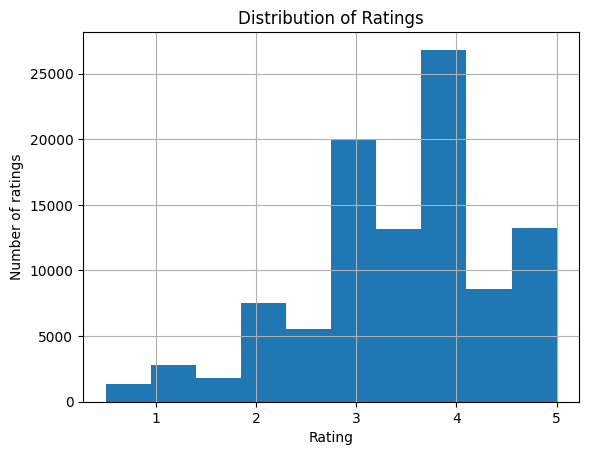

In [34]:
import matplotlib.pyplot as plt
ratings["rating"].hist(bins=10)
plt.xlabel("Rating")
plt.ylabel("Number of ratings")
plt.title("Distribution of Ratings")

In [35]:
ratings_per_user = ratings.groupby("userId").size()
ratings_per_user.head()


userId
1    232
2     29
3     39
4    216
5     44
dtype: int64

Text(0.5, 1.0, 'Distribution of Ratings per User')

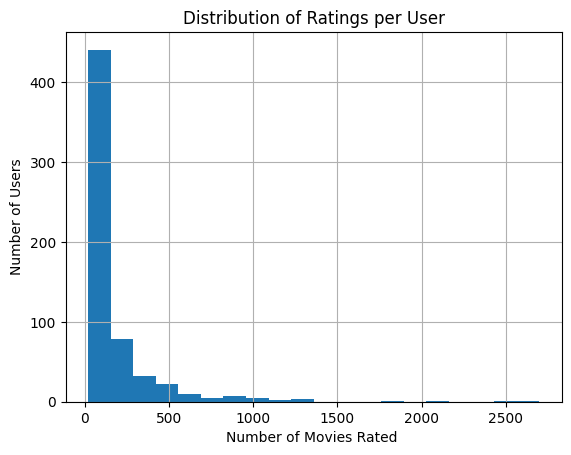

In [36]:
ratings_per_user.hist(bins=20)
plt.xlabel("Number of Movies Rated ")
plt.ylabel("Number of Users")
plt.title("Distribution of Ratings per User")


(0.0, 200.0)

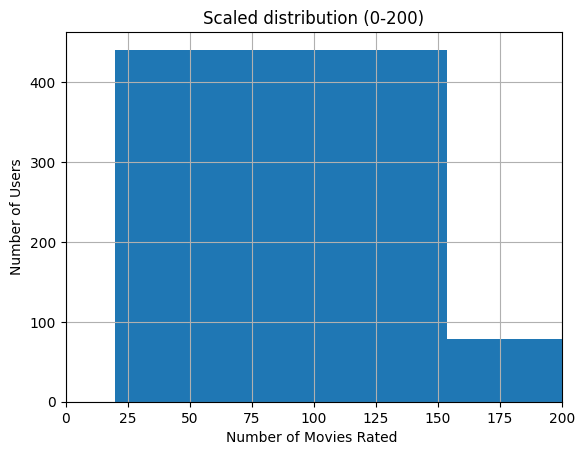

In [37]:
ratings_per_user.hist(bins=20)
plt.xlabel("Number of Movies Rated ")
plt.ylabel("Number of Users")
plt.title("Scaled distribution (0-200)")
plt.xlim(0,200)

In [38]:
def get_co_rated(matrix,a,b,axis):
    if axis == "index":
        x=matrix.loc[a]
        y=matrix.loc[b]
    elif axis == "columns":
        x=matrix[a]
        y=matrix[b]
    else:
        print("axis must be either 'index' or 'columns'")
    mask = x.notna() & y.notna()
    return x[mask],y[mask]


In [39]:
import numpy as np
def euclidean_similarity(vec1, vec2):
    distance = np.sqrt(np.sum((vec1-vec2)**2))
    similarity = 1/ (1+distance)
    return similarity


In [40]:
def cosine_similarity(vec1, vec2):
    dot_product = np.dot(vec1,vec2)
    norm1 = np.linalg.norm(vec1)
    norm2 = np.linalg.norm(vec2)

    similarity = dot_product / (norm1*norm2)
    return similarity


In [41]:
def pearson_similarity(vec1, vec2):
    mean1 = np.mean(vec1)
    mean2 = np.mean(vec2)
    centered1 = vec1 - mean1
    centered2 = vec2 - mean2

    return cosine_similarity(centered1,centered2)

In [ ]:
def find_k_nearest_users(matrix, target_user, k, similarity_fn):

    similarities = []
    for user in matrix.index:
        if user==target_user:
            continue
        else:
            vector1,vector2=get_co_rated(matrix,target_user,user,"index") 

        if len(vector1)<2:
            continue
        elif similarity_fn==euclidean_similarity:
            score=euclidean_similarity(vector1,vector2)
        elif similarity_fn==cosine_similarity:
            score=cosine_similarity(vector1,vector2)       
        elif similarity_fn==pearson_similarity:
            score=pearson_similarity(vector1,vector2)
        else:
            print("Please select a valid similarity function") 
            return None

        if score is None:
            continue
        similarities.append((user,score))

    similarities.sort(key=lambda x:x[1],reverse=True)
    return similarities[:k]


In [43]:
def predict_rating_user_based(matrix, target_user, target_item, k, similarity_fn):
    num=0
    den=0
    nearestk=find_k_nearest_users(matrix,target_user,k,similarity_fn)

    for userid,score in nearestk:
        if np.isnan(matrix.loc[userid,target_item]):
            continue
        else: 
            num+=score*matrix.loc[userid,target_item]
            den+=abs(score)

    if den==0:
        return None
    else:
        return num/den

In [ ]:
def find_k_nearest_items(matrix, target_item, k, similarity_fn):
    similarities = []
    for item in matrix.columns:
        if item==target_item:
            continue
        else:
            vector1,vector2=get_co_rated(matrix,target_item,item,"columns") 
    
        if len(vector1)<2:
            continue
        elif similarity_fn==euclidean_similarity:
            score=euclidean_similarity(vector1,vector2)
        elif similarity_fn==cosine_similarity:
            score=cosine_similarity(vector1,vector2)       
        elif similarity_fn==pearson_similarity:
            score=pearson_similarity(vector1,vector2)
        else:
            print("Please select a valid similarity function") 
            return None
    
        if score is None:
            continue
        similarities.append((item,score))
    
    similarities.sort(key=lambda x:x[1],reverse=True)
    return similarities[:k]

In [ ]:
def predict_rating_item_based(matrix, target_user, target_item, k, similarity_fn):
    num=0
    den=0
    nearestk=find_k_nearest_items(matrix,target_item,k,similarity_fn)

    for itemid,score in nearestk:
        if np.isnan(matrix.loc[target_user,itemid]):
            continue
        else: 
            num+=score*matrix.loc[target_user,itemid]
            den+=abs(score)

    if den==0:
        return None
    else:
        return num/den